OVERVIEW: Observe a bright source for different integration times. Rapidly repoint to position the boresight on a nearby blank part of the sky. Continue to read out detector afterwards to quantify persistence.
    Even observations, therefore, are pointing at the bright source. Odd observations are pointing away. 
    Note: there is likely little value in doing this for multiple targets. 

DATA PRODUCTS:  RD-A4: estimate of decay time of charge on the NIR detector from a bright source (RD-A4)


EXIT CRITERIA: observation obtained, analysis complete and summarized in 3.30_ResultsSummary.md
    Data with a TBD NIR S/N while source was on NIR array immediately followed by TBD duration of observation of blank sky.


DATA VOLUME: 20 observations, simultaneous NIR and VIS. 


TARGET CRITERIA: bright source near, but bellow, saturation. Nearby blank part of the sky - any objects below sensitivity limit for the NIR FOV.


KEY STAKEHOLDERS: Christina Hedges, Tom Barclay

## Load in 

In [1]:
''' Make sure you have pandorasim installed and updated '''
# pandorasim, Version: 1.0.10
# pandorasat, Version: 0.5.22

import pandorasat as ps
import pandorasim as pp
ps.utils.get_phoenix_model(teff=7000, jmag=10) ### this is a temporary fix to an import error with pandorasim
from pandorasim import VisibleSim, NIRSim
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord, Longitude
from astropy.io import fits
from pandorasat.plotting import animate
from pandorasat.plotting import save_mp4, save_gif
from astropy.time import Time, TimeDelta
import matplotlib.patches as patches

### Importing additional functions and constants used in this notebook
import sys, os
sys.path.append(os.path.abspath('..'))
from CommissFunctions import generate_task_plan 
from CommissFunctions import data_rate, bits_per_pix_VIS, compression_fractor_VIS, frame_time_VIS, stored_frames_per_int_VIS, pass_time_min, regions_NIR, bits_per_pix_NIR, compression_fractor_NIR, NIR_ra_shape, NIR_dec_shape, VIS_ra_shape, VIS_dec_shape


/Users/lindseywiser/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Data Volume

20 observations, simultaneous VIS and NIR: VIS Observations come in two types. NIR Observations come in three types.

- VIS type 1: 9 subarrays, 50x50, 360 integrations
- VIS type 2: 9 subarrays, 50x50, 10 integrations

- NIR type 1: 84x400 subarray, 24 frames per integration, 24 resultant stored, 429 integrations
- NIR type 2: 84x400 subarray, 24 frames per integration, 24 resultant stored, 12 integrations
- NIR type 3: 84x400 subarray, 24 frames per integration, 2 resultant stored, 429 integrations

In [2]:
num_observations = 20 

VIS_type2_obsnums = [0, 2, 4, 6, 8] # observation numbers with VIS Type 2, zero indexed
NIR_type2_obsnums = [0, 2, 4, 6, 8] # observation numbers with NIR Type 2, zero indexed
NIR_type3_obsnums = [10, 12, 14, 16, 18] # observation numbers with NIR Type 3, zero indexed

In [3]:
##### VIS Observation Constants #####
frames_per_int_VIS      = 50
regions_VIS             = 9
VIS_xpix                = 50
VIS_ypix                = 50
bits_per_int_VIS        = VIS_xpix * VIS_ypix * regions_VIS * bits_per_pix_VIS * stored_frames_per_int_VIS
int_and_reset_time_VIS  = frame_time_VIS * frames_per_int_VIS
bits_per_sec_VIS        = bits_per_int_VIS / int_and_reset_time_VIS
bits_per_sec_comp_VIS   = bits_per_sec_VIS / compression_fractor_VIS

##### VIS Observations -- type 1 #####
num_int_VIS1            = 360
test_time_VIS1          = num_int_VIS1 * int_and_reset_time_VIS
bits_test_total_VIS1    = bits_per_sec_comp_VIS * test_time_VIS1
Gbits_test_packet_VIS1  = bits_test_total_VIS1 / 1E9 * 1.1 * 1.25
downlinks_VIS1          = Gbits_test_packet_VIS1 * 1E9 / (data_rate * 1E6) /60 /pass_time_min 

print('VIS Observations, Type 1:', Gbits_test_packet_VIS1*(num_observations-len(VIS_type2_obsnums)), 'Gbits')

##### VIS Observations -- type 2 #####
num_int_VIS2            = 10
test_time_VIS2          = num_int_VIS2 * int_and_reset_time_VIS
bits_test_total_VIS2    = bits_per_sec_comp_VIS * test_time_VIS2
Gbits_test_packet_VIS2  = bits_test_total_VIS2 / 1E9 * 1.1 * 1.25
downlinks_VIS2          = Gbits_test_packet_VIS2 * 1E9 / (data_rate * 1E6) /60 /pass_time_min 

print('VIS Observations, Type 2:', Gbits_test_packet_VIS2*len(VIS_type2_obsnums), 'Gbits')


VIS Observations, Type 1: 1.7820000000000003 Gbits
VIS Observations, Type 2: 0.0165 Gbits


In [4]:
##### NIR Observation Constants #####
NIR_xpix                  = 84
NIR_ypix                  = 400
frames_per_int_NIR        = 24
frame_time_NIR            = NIR_xpix * NIR_ypix * 0.00001 #sec 
int_and_reset_time_NIR    = frame_time_NIR * (frames_per_int_NIR+1)

##### NIR Observations -- Type 1 #####
stored_frames_per_int_NIR1 = 24
num_int_NIR1               = 429
bits_per_int_NIR1          = NIR_xpix * NIR_ypix * regions_NIR * bits_per_pix_NIR * stored_frames_per_int_NIR1
bits_per_sec_NIR1          = bits_per_int_NIR1 / int_and_reset_time_NIR
test_time_NIR1             = num_int_NIR1 * int_and_reset_time_NIR
bits_per_sec_comp_NIR1     = bits_per_sec_NIR1 / compression_fractor_NIR
bits_test_total_NIR1       = bits_per_sec_comp_NIR1 * test_time_NIR1
Gbits_test_packet_NIR1     = bits_test_total_NIR1 / 1E9 * 1.1 * 1.25
downlinks_NIR1             = Gbits_test_packet_NIR1 * 1E9 / (data_rate * 1E6) /60 /pass_time_min

print('NIR Observations, Type 1:', Gbits_test_packet_NIR1 * (num_observations-len(NIR_type2_obsnums)-len(NIR_type2_obsnums)), 'Gbits')

##### NIR Observations -- Type 2 #####
stored_frames_per_int_NIR2 = 24
num_int_NIR2               = 12
bits_per_int_NIR2          = NIR_xpix * NIR_ypix * regions_NIR * bits_per_pix_NIR * stored_frames_per_int_NIR2
bits_per_sec_NIR2          = bits_per_int_NIR2 / int_and_reset_time_NIR
test_time_NIR2             = num_int_NIR2 * int_and_reset_time_NIR
bits_per_sec_comp_NIR2     = bits_per_sec_NIR2 / compression_fractor_NIR
bits_test_total_NIR2       = bits_per_sec_comp_NIR2 * test_time_NIR2
Gbits_test_packet_NIR2     = bits_test_total_NIR2 / 1E9 * 1.1 * 1.25
downlinks_NIR2             = Gbits_test_packet_NIR2 * 1E9 / (data_rate * 1E6) /60 /pass_time_min

print('NIR Observations, Type 2:', Gbits_test_packet_NIR2 * len(NIR_type2_obsnums), 'Gbits')

##### NIR Observations -- Type 3 #####
stored_frames_per_int_NIR3 = 2
num_int_NIR3               = 429
bits_per_int_NIR3          = NIR_xpix * NIR_ypix * regions_NIR * bits_per_pix_NIR * stored_frames_per_int_NIR3
bits_per_sec_NIR3          = bits_per_int_NIR3 / int_and_reset_time_NIR
test_time_NIR3             = num_int_NIR3 * int_and_reset_time_NIR
bits_per_sec_comp_NIR3     = bits_per_sec_NIR3 / compression_fractor_NIR
bits_test_total_NIR3       = bits_per_sec_comp_NIR3 * test_time_NIR3
Gbits_test_packet_NIR3     = bits_test_total_NIR3 / 1E9 * 1.1 * 1.25
downlinks_NIR3             = Gbits_test_packet_NIR3 * 1E9 / (data_rate * 1E6) /60 /pass_time_min

print('NIR Observations, Type 3:', Gbits_test_packet_NIR3 * len(NIR_type3_obsnums), 'Gbits')


NIR Observations, Type 1: 38.05401600000002 Gbits
NIR Observations, Type 2: 0.532224 Gbits
NIR Observations, Type 3: 1.5855840000000003 Gbits


### Total Data Volume

In [5]:
Gbits_VIS_total = (Gbits_test_packet_VIS1*(num_observations-len(VIS_type2_obsnums))) + Gbits_test_packet_VIS2*len(VIS_type2_obsnums)
Gbits_NIR_total = (Gbits_test_packet_NIR1 * (num_observations-len(NIR_type2_obsnums)-len(NIR_type2_obsnums))) + (Gbits_test_packet_NIR2 * len(NIR_type2_obsnums)) + (Gbits_test_packet_NIR3 * len(NIR_type3_obsnums))
Gbits_total = Gbits_VIS_total + Gbits_NIR_total

downlinks_VIS_total = (downlinks_VIS1*(num_observations-len(VIS_type2_obsnums))) + downlinks_VIS2*len(VIS_type2_obsnums)
downlinks_NIR_total = (downlinks_NIR1 * (num_observations-len(NIR_type2_obsnums)-len(NIR_type2_obsnums))) + (downlinks_NIR2 * len(NIR_type2_obsnums)) + (downlinks_NIR3 * len(NIR_type3_obsnums))
downlinks_total = downlinks_VIS_total + downlinks_NIR_total

# Currently, the NIR observations take slightly longer than VIS, so we can just add those
test_time_total = (test_time_NIR1 * (num_observations-len(NIR_type2_obsnums)-len(NIR_type2_obsnums))) + (test_time_NIR2 * len(NIR_type2_obsnums)) + (test_time_NIR3 * len(NIR_type3_obsnums))

print('Test time, total, no slew/overhead time:', test_time_total/60/60, 'hours')
print('Volume, total:', Gbits_total, 'Gbits')
print('Downlinks, total:', downlinks_total)

Test time, total, no slew/overhead time: 15.155 hours
Volume, total: 41.97032400000001 Gbits
Downlinks, total: 17.487635000000008


In [6]:
### Adding important variables to a dictionary for later
obs_dict = {
    'VIS1': {'test_time': test_time_VIS1, 'num_int': num_int_VIS1},
    'VIS2': {'test_time': test_time_VIS2, 'num_int': num_int_VIS2},
    
    'NIR1': {'test_time': test_time_NIR1, 'stored_frames_per_int': stored_frames_per_int_NIR1, 'num_int': num_int_NIR1},
    'NIR2': {'test_time': test_time_NIR2, 'stored_frames_per_int': stored_frames_per_int_NIR2, 'num_int': num_int_NIR2},
    'NIR3': {'test_time': test_time_NIR3, 'stored_frames_per_int': stored_frames_per_int_NIR3, 'num_int': num_int_NIR3}
}

## The rest of this notebook should be run for each of the 20 observations. Select an observation number

In [13]:
observation_number = 0

vis='VIS1'
nir='NIR1'
if np.isin(observation_number, VIS_type2_obsnums): 
    vis='VIS2'
if np.isin(observation_number, NIR_type2_obsnums): 
    nir='NIR2'
if np.isin(observation_number, NIR_type3_obsnums): 
    nir='NIR3'

## Define Bright Target

For observation_number = odd numbers, we will point away from the source.

In [16]:
''' Finds target coordinates based on astropy '''
### You can do this differently as long as you have DEC and RA
target = "GJ 3470"
c = SkyCoord.from_name(target)


''' Identify the start time and end time of the observation '''
start_time = Time.now() # starting now. This should get overridden by the scheduler. 
test_time = max(obs_dict[vis]['test_time'], obs_dict[nir]['test_time'])
time_delta = TimeDelta(test_time, format='sec')
end_time = start_time + time_delta


''' Initialize a simulator object '''
### Set the number of ROIs and their sizes. 
### For now, NIRSim does not allow you to set the ROI_size. But we can still set it in the SOC file at the end.
simVIS = VisibleSim(ROI_size=(VIS_xpix, VIS_ypix), nROIs=regions_VIS) 
simNIR = NIRSim() # NIRSim(ROI_size=(obs_dict[nir]['xpix'], obs_dict[nir]['ypix']))

Output()

Output()

In [19]:
''' You can print the shape of the VIS or NIR array, if useful: ''' 
#print('VIS:', VIS_ra_shape.to(u.deg)/2)
#print('NIR:', NIR_ra_shape.to(u.deg)/2)

' You can print the shape of the VIS or NIR array, if useful: '

In [20]:
''' Define the center of our observation -- move away from target for odd observations '''
ra0        = c.ra
dec0       = c.dec
theta0     = 0*u.deg

if observation_number % 2 == 1:  ### Adjust this based on where the "empty" part of the sky is
    ra0        = c.ra -0.5*u.deg 
    dec0       = c.dec -0.5*u.deg 
    theta0     = 0*u.deg


''' Point the simulator to the corrected location '''
###        RA,   DEC,    Theta 
simVIS.point(ra0, dec0, theta0)
simNIR.point(ra0, dec0, theta0) ### this line has an known error. 

Output()

Output()

Output()

Output()

Output()

2025-03-04 12:08:24 WARNING: 0.0K source in catalog is not modelable. Setting to 2000K.

Output()

## Generate Observation

### VIS Observation

<Axes: title={'center': 'VISDA\n(RA:119.77 deg, Dec:15.39 deg, Roll:0.00 deg)'}, xlabel='Column [pixel]', ylabel='Row [pixel]'>

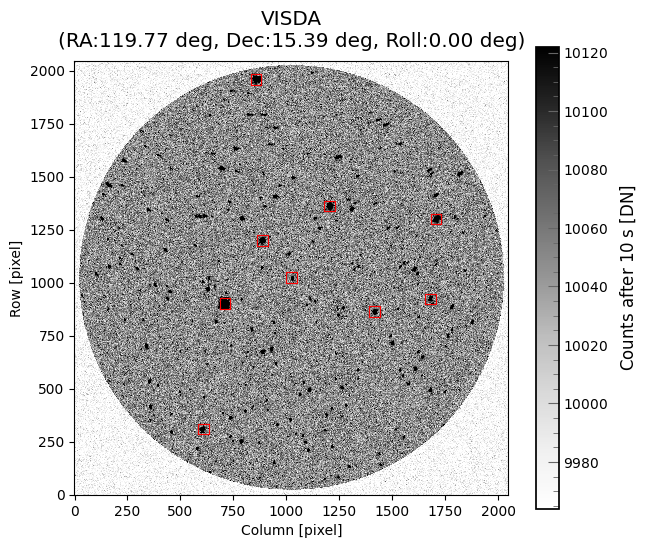

In [21]:
''' Plot the VIS Full Frame Image. ROIs are in red boxes defining the subarrays. '''
simVIS.show_FFI()

In [22]:
''' Create an Observation. '''
### This returns an astropy.io.fits.HDUList array. 
# `nreads` sets how many reads of the detector are coadded together to create a frame.
# `bin_frames` is a shortcut parameter to speed up computation. Must be a factor of nreads. We can ignore this for low nreads. 
# `nframes` sets how many frames will be returned.
# `start_time` indicates the time of observation. 
# `output_type` is set to array, for now. This make it easy to call, but we'll save it as a fits file later. 
###

### reduce the number of integrations to speed up calculations
reduction = 1 # set to 1 for no reduction
data = simVIS.observe(nreads=frames_per_int_VIS, bin_frames=1, nframes=int(obs_dict[vis]['num_int']/reduction), start_time=start_time, output_type="array")

### The shape is: (num ROIs, num frames, nrows, ncolumns)
data.shape

Modeling Pixel Positions: 100%|█████████████████| 16/16 [00:00<00:00, 21.66it/s]


(9, 10, 50, 50)

### NIR Observation

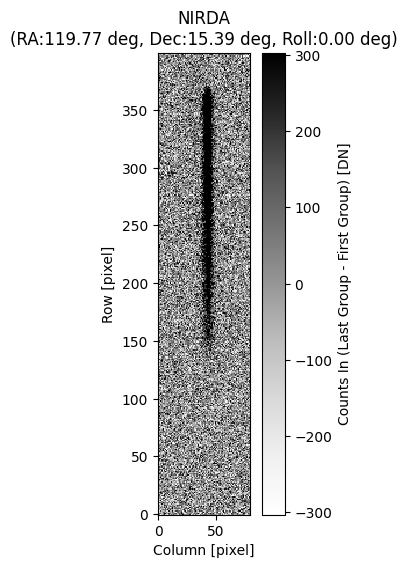

In [23]:
''' Plot the NIRDA subarray '''
simNIR.show_subarray();

In [25]:
''' Create a NIRDA observation. '''
### This returns an astropy.io.fits.HDUList array. The following parameters can be adjusted
# SC_Resets1 : Number of reset frames at the start of the first integration of exposure
# SC_Resets2 : Number of resent frames at the start of 1 through n integrations of exposure
# SC_DropFrames1 : Number of dropped frames after reset of any integration of exposure
# SC_DropFrames2 : Number of dropped frames in every group of integrations of exposure except the last group
# SC_DropFrames3 : Number of dropped frames in the last group of each integration of exposure
# SC_ReadFrames : Number of frames read during each group of integration of exposure
# SC_Groups : Number of groups per integration of exposure
# SC_Integrations : Number of integrations per exposure
# start_time : Time to start the observation. This is only used if returning a fits file, or supplying a flux function.
# noise : bool flag determining whether noise is simulated and included. Default is True.
# jitter : bool flag determining whether jitter is simulated and included. Default is True.
# output_type : String flag to determine the result output. Valid strings are "fits" or "array
###

ROIsize_override = (NIR_xpix, NIR_ypix) ### THIS CANNOT YET BE SPECIFIED IN sim.observe()

data = simNIR.observe(SC_DropFrames1=frames_per_int_NIR-obs_dict[nir]['stored_frames_per_int'], SC_Integrations=obs_dict[nir]['num_int'], SC_ReadFrames=obs_dict[nir]['stored_frames_per_int'], start_time=start_time, output_type="array")

### The shape is: (num ROIs, num frames, nrows, ncolumns)
data.shape

Modeling Pixel Positions: 100%|█████████████████| 11/11 [00:36<00:00,  3.28s/it]


(12, 2, 400, 80)

## Save the Simulated Observation

In [26]:
''' Re-Create the observations in the correct format for the .fits file (i.e., output_type set to default) '''
### Before, object_type was array for easy computation in this notebook, but that is not correct for the .fits file
hdulist_vis = simVIS.observe(nreads=frames_per_int_VIS, bin_frames=1, nframes=int(obs_dict[vis]['num_int']/reduction), start_time=start_time)
hdulist_nir = simNIR.observe(SC_DropFrames1=frames_per_int_NIR-obs_dict[nir]['stored_frames_per_int'], SC_Integrations=obs_dict[nir]['num_int'], SC_ReadFrames=obs_dict[nir]['stored_frames_per_int'], start_time=start_time)


''' Save our simulated observation in a fits file '''
targ = target.replace(" ", "")
VISrois_outfile = "3.30_VISrois_"+str(targ)+"_obs"+str(observation_number)+".fits"
NIRrois_outfile = "3.30_NIRrois_"+str(targ)+"_obs"+str(observation_number)+".fits"
hdulist_vis.writeto(VISrois_outfile, overwrite=True)
hdulist_nir.writeto(NIRrois_outfile, overwrite=True)

Modeling Pixel Positions: 100%|███████████████████| 9/9 [00:34<00:00,  3.84s/it]


In [27]:
### Show what is in our fits file: 
'''
Three FITS file extensions: 
    (1) PRIMARY: information about the simulated observation 
    (2) SCIENCE: data info, images
    (3) ROITABLE: VISDA pixel coordinates of the origin of the subarray, which is defined as the lower left corner
'''

hdul_rois = fits.open(VISrois_outfile) ### or NIRrois_outfile
print(hdul_rois.info())

#print('.')
#print('.')
#print('.')
#print('-- PRIMARY Headers --')
#print(hdul_rois[0].header)

#print('.')
#print('.')
#print('.')
#print('-- SCIENCE Headers --')
#print(hdul_rois[1].header)

#print('.')
#print('.')
#print('.')
#print('-- ROITABLE Headers --')
#print(hdul_rois[2].header)

Filename: 3.30_VISrois_GJ3470_obs0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   ()      
  1  SCIENCE       1 ImageHDU        71   (150, 150, 10)   int64   
  2  ROITABLE      1 BinTableHDU     36   2R x 9C   [D, K, K, K, K, K, K, K, K]   
None


## Data Products

### RD-A4: estimate of decay time of charge on the NIR detector from a bright source (RD-A4)

## Generate SOC File

In [30]:
'Here we define the information required for scheduling the observation.'''
### Some variables may be removed/added/changed. Working on defining these with SOC meetings. 
### This is not all correct! Revisit and check once notebook is complete. 

variables = {
    'visit_id': '0330', ### setting based on task number. Could change. 
    'obs_id': f"{observation_number:03}", ### setting based on observation number. 
    'target': target, 
    'priority': 1, ### all commissioning is priority 1
    'start_time': start_time, 
    'stop_time': end_time, 
    'RA': ra0,
    'DEC': dec0, 
    
    'NIR_AvgGroups': 2, ### check what this is
    'NIR_ROI_StartX': ra0, 
    'NIR_ROI_StartY': dec0, 
    'NIR_ROI_SizeX': NIR_xpix, 
    'NIR_ROI_SizeY': NIR_ypix,
    'NIR_SC_Resets1': 1,
    'NIR_SC_Resets2': 1, 
    'NIR_SC_DropFrames1': 0,
    'NIR_SC_DropFrames2': 16,
    'NIR_SC_DropFrames3': 0, 
    'NIR_SC_ReadFrames': frames_per_int_NIR,
    'NIR_targetID': target, 
    'NIR_SC_Groups': 2,
    'NIR_SC_Integrations': obs_dict[nir]['num_int'], 
    
    'VIS_StarRoiDetMethod': 0,  ### 0: monitor stars at positions defined in [PredefinedStarRoiRa, PredefinedStarRoiDec]. 1: Run star detection algorithm on first image and obtain star ROIs from results.
    'VIS_FramesPerCoadd': frames_per_int_VIS, 
    'VIS_NumTotalFramesRequested': obs_dict[vis]['num_int'], 
    'VIS_TargetRA': ra0, 
    'VIS_TargetDEC': dec0, 
    'VIS_IncludeFieldSolnsInResp': 1, ### Determines whether the Ra/Dec/Rot values calculated for each frame in the visible science collect will be included in the response message [1] or not [0].
    'VIS_StarRoiDimension': [VIS_xpix, VIS_ypix], 
    'VIS_MaxNumStarRois': '', ### max number of star ROIs that will be used for coadding signal from target stars if StarRoiDetMethod == 1.
    'VIS_numPredefinedStarRois': regions_VIS, ### If StarRoiDetMethod==0, this is the number of [RA, DEC] coordinates contained in the PredefinedStarRoiRA and PredefinedStarRoiDEC vectors.
    'VIS_PredefinedStarRoiRa': '', ### currently defining as corner of ROI. We may update this to be ROI centers.
    'VIS_PredefinedStarRoiDec': '', 
    'VIS_targetID': target, 
    'VIS_NumExposuresMax': obs_dict[vis]['num_int'], 
    'VIS_ExposureTime_us': frame_time_VIS * 1000000  
}

In [31]:
'''Generate the SOC .xml file'''

output_soc_file = variables['visit_id']+'_'+variables['obs_id']+'_example_SOC.xml' 
generate_task_plan(variables, output_soc_file)